# Unidad 1. Regresión lineal simple y correlación

## Medidas de dispersión
Suma de los cuadrados de las desviaciones de los valores de $X$ con respecto a su media:
$$ S_{xx} = \sum_{i=1}^{n} (X_i - \bar{X})^2 $$
Suma de los productos de las desviaciones de los valores de $X$ y $Y$ con respecto a sus medias:
$$S_{xy} = \sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})$$
Suma de los cuadrados de las desviaciones de los valores de $Y$ con respecto a su media:
$$ S_{xx} = \sum_{i=1}^{n} (Y_i - \bar{Y})^2 $$

## Recta de regresión ajustada
La regresión lineal ajustada se representa mediante estadísticos:
$$ \hat{Y} = b_0 + b_1 X $$
donde $\hat{Y}$ representa el valor de $Y$ obtenido mediante la recta de regresión ajustada (no la verdadera $Y$). Los estadísticos $b_0$ y $b_1$ se calculan de la siguiente manera:

$$b_1 = \frac{S_{xy}}{S_{xx}}$$

$$ b_0 = \bar{Y} - b_1 \bar{X} $$

texto en cursiva## Sumas de cuadrados SS (Sum of Squares)
Suma de los Cuadrados de los Errores:
$$ SSE = \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2 = \sum_{i=1}^n e_i^2$$
Suma total de cuadrados:
$$SST = \sum_{i=1}^{n} (Y_i - \bar{Y})^2$$
Suma de cuadrados de regresión:
$$SSR = \sum_{i=1}^{n} (\hat{Y_i} - \bar{Y})^2$$
- SST: Mide la variabilidad total de los datos observados.
- SSR: Mide la variabilidad de los datos que el modelo de regresión explica.
- SSE: Mide la variabilidad no explicada por el modelo (es decir, los residuos).

## Intervalo de confianza
Estadístico de prueba _t_:
$$t = \frac{b_1}{SE(b_1)}$$
Error estándar de $b_1$:
$$SE(b_1) = \frac{\sqrt{SSE / (n-2)}}   {\sqrt{S_{xx}} }$$
o
$$SE(b_1) = \frac{\sqrt{\sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2  / (n-2)}}   {\sqrt{S_{xx}} }$$

Intervalo de confianza para $b_1$:
$$b_1 - t_{\alpha/2} \cdot SE(b_1) \lt \beta_1 \lt b_1 + t_{\alpha/2} \cdot SE(b_1)$$
donde $n$ representa la cantidad de pares de datos.

## Comprobación de supuestos
Comprobar suposiciones:
- Test de shapiro a los residuales $e_i$: Para comprobar si la distribución es normal sobre la recta.
- Grafico $X$ vs $Y$: Para observar si los datos soportan la suposición de linealidad.
- Gráfico de residuales: Para observar si los datos soportan la suposición de linealidad, complementario al coeficiente de correlación
- Test de Breusch-Pagan: Para detectar heteroscedasticidad en regresion lineal

Test de Breusch-Pagan:<br>
`from statsmodels.stats.api import het_breuschpagan`<br>
Después, se obtiene el valor-p:<br>
`_, valor_p_bp, _, _ = het_breuschpagan(residuales, X)`
- $H_0$: Hay homoscedasticidad
- $H_1$: Hay heteroscedasticidad

## ANOVA en regresión lineal

| Fuente de variación | Suma de cuadrados (SS) | Grados de libertad (df) | Promedio de los cuadrados (MS) | Estadístico F |
|---------------------|------------------------|--------------------------|--------------------------------|---------------|
| Regresión  | $ SSR$ | $p$ | $MSR = \frac{SSR}{p}$ | $F = \frac{MSR}{MSE}$|
| Error | $SSE$| $n - p - 1 $| $MSE = \frac{SSE}{n - p - 1} $|     |
| Total | $SST $| $n - 1$|             |        |

donde $p$ es el número de parámetros para la recta de regresión ajustada (en la regresión simple $p=1$). Las hipótesis son:
$$H_0: \beta_1 = 0$$
$$H_1: \beta_1 \ne 0 $$

### Problema 1
Un profesor intenta mostrar a sus estudiantes la importancia de los exámenes cortos, aun cuando el 90% de la calificación final esté determinada por los exámenes parciales. Él cree que cuanto más altas sean las calificaciones de los exámenes cortos, más alta será la calificación final. Seleccionó una muestra aleatoria de 15 estudiantes de su clase con los siguientes datos:

| Promedio de exámenes cortos | Promedio final |
|--------------|--------------|
| 59 | 64 |
| 92 | 84 |
| 72 | 77 |
| 90 | 80 |
| 95 | 77 |
| 87 | 81 |
| 89 | 80 |
| 77 | 84 |
| 76 | 80 |
| 65 | 69 |
| 97 | 83 |
| 42 | 40 |
| 94 | 78 |
| 62 | 65 |
| 91 | 90 |



1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Tres estudiantes sacaron 70, 75 y 84 de calificación. Según la recta de regresión ajustada, ¿cuáles son los resultados esperados para estos tres alumnos?
12. Realice una tabla ANOVA e interprete el resultado.

In [358]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/jenni040422-ux/EstadisticaInferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_01.csv"
df = pd.read_csv(link_csv)
df


,promedio_de_examenes_cortos,promedio_final
0,59,64
1,92,84
2,72,77
3,90,80
4,95,77
5,87,81
6,89,80
7,77,84
8,76,80
9,65,69


1. Establesca una variable dependiente ($Y$) y una variable independiente ($X$).



* $Y$: Es el promedio final, porque es la variable que se quiere explicar o predecir.


* $X$: Es el promedio examenes cortos, porque es la variable que el profesor cree que puede influir en el resultado.

Esta elección es coherente, ya que busca analizar si mejorar en examenes cortos mejora el promedio final.

In [359]:
X = df['promedio_de_examenes_cortos']
Y = df['promedio_final ']

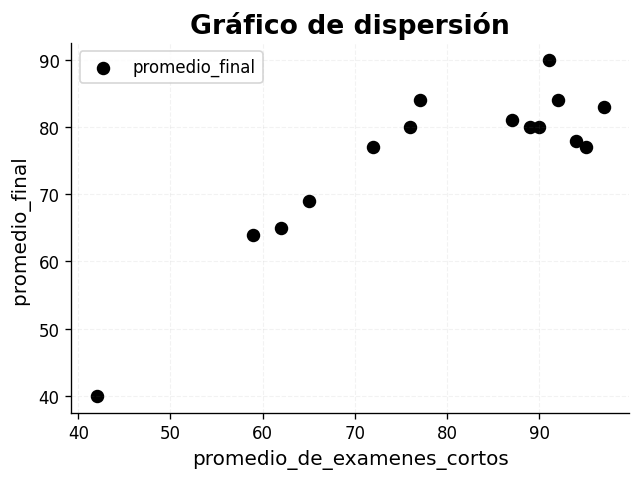

In [360]:
import matplotlib.pyplot as plt

# --- Definición de variables según tu imagen ---
X = df['promedio_de_examenes_cortos']
Y = df['promedio_final ']

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),  # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    X, Y,
    marker="o",        # forma de círculo negro
    color='black',     # color de los puntos
    edgecolor='black', # borde de los puntos
    alpha=1,           # transparencia
    s=50,              # tamaño de los puntos
    label='promedio_final'  # etiqueta para la leyenda corregida
)

# --- Título ---
plt.title(
    'Gráfico de dispersión',
    fontsize=16,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'promedio_de_examenes_cortos',
    fontsize=12
)
plt.ylabel(
    'promedio_final ',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False)  # derecha
plt.gca().spines['top'].set_visible(False)    # superior

# --- Cuadrícula ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
)
plt.show()

El gráfico refleja una correlación positiva: a medida que incrementan las notas de los exámenes cortos, el promedio final también tiende a subir. Si bien los puntos no se alinean de forma perfecta, muestran de manera evidente una dirección ascendente.

3. ¿Los datos soportan la suposición de linealidad?

El supuesto de linealidad se cumple de forma aceptable, ya que la distribución de los puntos describe una clara trayectoria ascendente.

4. Calcule el coeficiente de correlación e interprete el resultado.

In [361]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.8646
Valor p:  0.0000


El valor del coeficiente es $r = 0.8646$, lo cual señala una fuerte asociación positiva. Dado que el valor-p asciende a $0.000032$, se rechaza $H_0$, concluyendo que se presenta una relación lineal de carácter significativo entre los exámenes cortos y el promedio final.

5. Calcule el coeficiente de determinación e interprete el resultado.

In [362]:
import statsmodels.api as sm

X_constante = sm.add_constant(X)
modelo = sm.OLS(Y, X_constante).fit()
Y_calculada = modelo.predict(X_constante)

modelo.params

,0
const,24.526822
promedio_de_examenes_cortos,0.643180


La constante (24.53) es el promedio final estimado cuando las calificaciones de los exámenes cortos son cero. La pendiente (0.64) indica que por cada punto que aumenta el promedio de exámenes cortos, el promedio final aumenta en promedio 0.64 puntos.

In [363]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, Y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  74.75%


Con el coeficiente de determinación de: $r^2 = 0.7475$

El valor

$$r^2 = 0.7475$$

indica que el modelo explica aproximadamente el **74.75%** de la variación del promedio final. Esto significa que los exámenes cortos sí ayudan bastante a explicar el promedio final, aunque todavía hay otros factores que influyen.

6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.

In [364]:
modelo.params

,0
const,24.526822
promedio_de_examenes_cortos,0.643180


La ecuación de la recta es:

$$y = 24.526822 + 0.643180x$$

/tmp/ipykernel_2937/2895101740.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


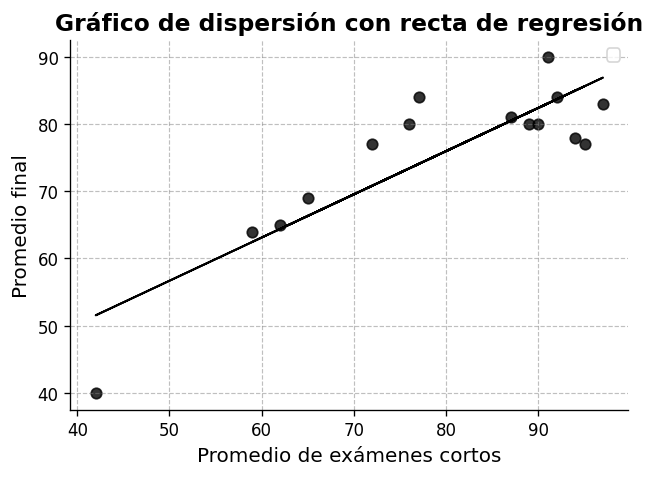

In [365]:
 import matplotlib.pyplot as plt
# --- Configuración general del gráfico--
plt.figure(
figsize=(6, 4), # tamaño de la figura (ancho, alto) en pulgadas
dpi=120 # resolución del gráfico
)
# --- Gráfico de dispersión --
plt.scatter(
X, Y,
marker="o", # forma
color='black', # color de los puntos (AHORA NEGRO)
edgecolor='black',# borde de los puntos (AHORA NEGRO)
alpha=0.8, # transparencia
s=40, # tamaño de los puntos
label=''
)
# --- Gráfico de línea --
plt.plot(
X, Y_calculada,
color='black', # color de la línea
linewidth=1.2, # grosor de la línea
linestyle='-', # estilo de línea continua
marker='o', # marcador en cada punto
markersize=0, # tamaño del marcador
markerfacecolor='white',
          markeredgecolor='black',
label=''
)
# --- Título --
plt.title(
'Gráfico de dispersión con recta de regresión',
fontsize=14,
fontweight='bold'
)
# --- Etiquetas de los ejes --
plt.xlabel(
'Promedio de exámenes cortos',
fontsize=12
)
plt.ylabel(
'Promedio final',
fontsize=12
)
# --- Fuente de los ticks --
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# --- Márgenes --
plt.margins(x=0.05, y=0.05) # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False)# derecha
plt.gca().spines['top'].set_visible(False) # superior
# --- Cuadrícula --
plt.grid(
visible=True,
linestyle='--', linewidth=0.7,# Corregido: eliminado 'n' extra
alpha=0.5,
color="gray"
)
# --- Leyenda --
plt.legend(
fontsize=10,
loc='best',
frameon=True
)
# --- Nota al pie --
plt.text(
0.4,-0.2,
'',
fontsize=8,
ha='left',
va='center',
transform=plt.gca().transAxes
)
# --- Guardar gráfico --
plt.savefig(
"grafico_dispersion_linea_negro.png",
bbox_inches='tight'
)
plt.show()

Esto significa que por cada punto adicional en el promedio de exámenes cortos, el promedio final esperado aumenta aproximadamente 0.64 puntos.

7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)

In [366]:
modelo.conf_int(alpha=0.05)

,0,1
const,6.441997,42.611646
promedio_de_examenes_cortos,0.419219,0.867141


El intervalo para la pendiente es 0.419219, 0.867141. Como el intervalo no contiene al cero, la pendiente es significativa; por lo tanto, sí se acepta que $X$ tiene efecto sobre $Y$

8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?

In [367]:
residuales = modelo.resid

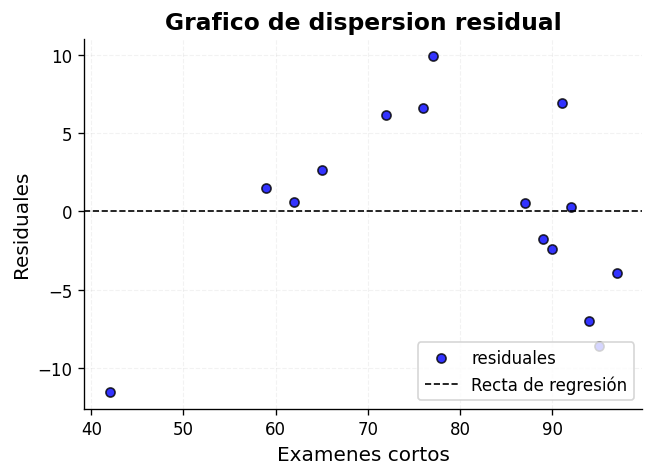

In [368]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),    # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120            # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    X, residuales,
    marker="o",        # forma
    color='blue',      # color de los puntos
    edgecolor='black', # borde de los puntos
    alpha=0.8,         # transparencia
    s=30,              # tamaño de los puntos
    label='residuales'   # etiqueta para la leyenda
)

plt.axhline(
    y=0,               # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle="--",    # Estilo de línea
    color="black",     # color
    linewidth=1.0,     # ancho de línea
)

# --- Título ---
plt.title(
    'Grafico de dispersion residual',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Examenes cortos',
    fontsize=12
)

plt.ylabel(
    'Residuales',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula ---
plt.grid(
    visible=True,
    linestyle='--', linewidth=0.7, # Corregido: eliminado 'n' extra
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
)

plt.show()



*   Linealidad: Se verifica satisfactoriamente, dado que las observaciones muestran un comportamiento alineado de dirección ascendente.
*   Normalidad: Se acepta de manera favorable ya que la prueba de Shapiro arroja un valor de $p = 0.9018$, el cual supera el umbral de $0.05$.

*   Homoscedasticidad: Se acepta debido a que el resultado de Breusch-Pagan presenta un valor de $p = 0.02289$.
*   Independencia: Se da por sentada partiendo de que los datos corresponden a distintos alumnos.





9. Realice la prueba de Shapiro para los residuales y comente el resultado.

valor-p (Shapiro) = 0.901827735700704


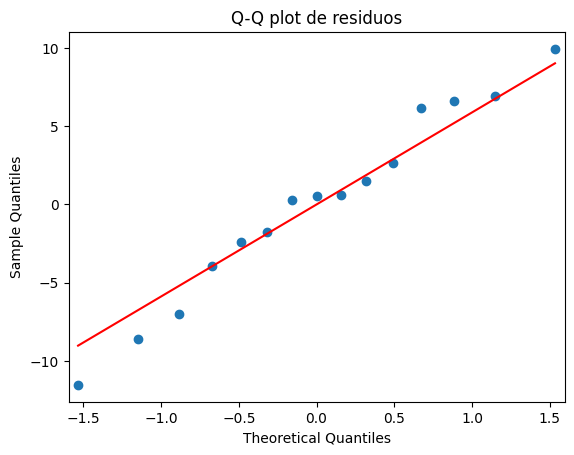

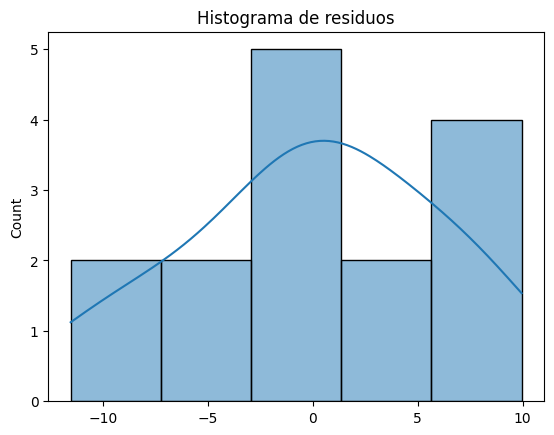

In [369]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm # Añadir import para sm si no está en scope

# test de Shapiro-Wilk
# H0: Hay normalidad
# H1: No hay normalidad

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

La hipótesis nula dice que los residuales siguen una distribución normal. Como $p = 0.9018 > 0.05$, no se rechaza $H_0$; por lo tanto, se acepta que los residuales se comportan de forma normal.

**10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [370]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm

# X_constante ya debe estar definido si kLeFaWcZuyHg fue ejecutado
_, valor_p_bp, _, _ = het_breuschpagan(residuales, X_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.2289



La hipótesis nula postula que existe homocedasticidad, es decir, varianza constante en los residuales. Como $p = 0.2289 > 0.05$, no se rechaza $H_0$; por eso se acepta que no hay un problema importante de heterocedasticidad.

**11. Tres estudiantes sacaron 70, 75 y 84 de calificación. Según la recta de regresión ajustada, ¿cuáles son los resultados esperados para estos tres alumnos?**

In [371]:
modelo.predict([1, 70])

array([69.54941193])

In [372]:
modelo.predict([1, 75])

array([72.76531124])

In [373]:
modelo.predict([1, 84])

array([78.55393001])

Para el estudiante con 70 de calificación: 69.55 (exactamente 69.5494).  
 Para el estudiante con 75 de calificación: 72.77 (exactamente 72.7653).  
  Para el estudiante con 84 de calificación: 78.55 (exactamente 78.5539).

**12. Realice una tabla ANOVA e interprete el resultado.**

In [374]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

df_anova = pd.DataFrame({
    'promedio_final': Y,
    'promedio_de_examenes_cortos': X
})

modelo_lineal = ols('promedio_final ~ promedio_de_examenes_cortos', data=df_anova).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
promedio_de_examenes_cortos,1.0,1538.228959,1538.228959,38.492412,0.000032
Residual,13.0,519.504375,39.961875,NaN,NaN


**Problema 2**

William Hawkins, vicepresidente de personal de la International Motors, trabaja en la relación entre el salario de un trabajador y el porcentaje de ausentismo. Hawkins dividió el intervalo de salarios de International en 12 grados o niveles (1 es el menor grado, 12 el más alto) y después muestreó aleatoriamente a un grupo de trabajadores. Determinó el grado de salario de cada trabajador y el número de días que ese empleado había faltado en los últimos 3 años.

| Categoría de salario | 11 | 10 | 8 | 5 | 9 | 7 | 3 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| **Ausencias** | 18 | 17 | 29 | 36 | 11 | 28 | 35 |

| Categoría de salario | 11 | 8 | 7 | 2 | 9 | 8 | 3 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| **Ausencias** | 14 | 20 | 32 | 39 | 16 | 31 | 40 |

---

1. Establezca una variable dependiente ($Y$) y una variable independiente ($X$).
2. Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$).
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [375]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/jenni040422-ux/EstadisticaInferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_02.csv"
df = pd.read_csv(link_csv)
df

,salario,ausencias
0,11,18
1,10,17
2,8,29
3,5,36
4,9,11
5,7,28
6,3,35
7,11,14
8,8,20
9,7,32


**1. Establezca una variable dependiente ($Y$) y una variable independiente ($X$).**

* **$Y$**: es el salario, porque es la variable que se desea explicar ya que busca analizar si faltar mas días se relaciona con un menor nivel salarial.

* **$X$**: son las ausencias, porque puede influir en la categoría de salario.

In [376]:
X=df['ausencias']
Y=df['salario']

**2. Realice un diagrama de dispersión para estos datos.**

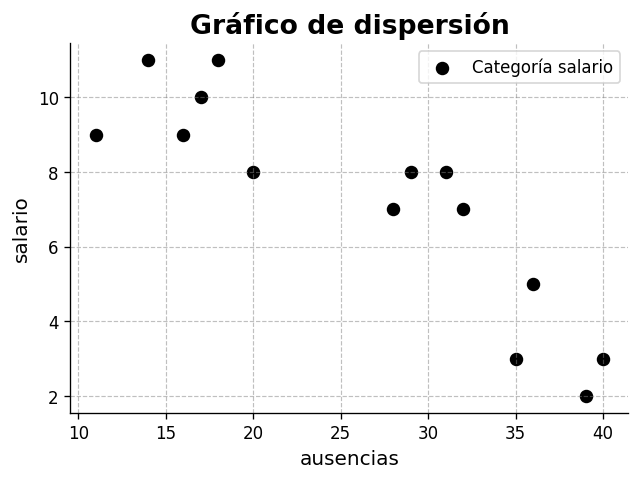

In [377]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    X, Y,
    marker="o",       # forma de círculo
    color='black',    # color de los puntos (negro)
    edgecolor='black',# borde de los puntos
    alpha=1,          # transparencia
    s=50,             # tamaño de los puntos
    label='Categoría salario' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión',
    fontsize=16,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'ausencias',
    fontsize=12
)

plt.ylabel(
    'salario',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula más visible ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
)

plt.show()
#Jennifer Hernández Gallegos

El diagrama muestra una tendencia descendente. Esto significa que, en general, los trabajadores con más ausencias tienden a tener una categoría salarial más baja.

**3. ¿Los datos soportan la suposición de linealidad?**

Sí, porque existe una tendencia, pero en sentido negativo; los puntos se acomodan alrededor de una línea descendente, por lo que la regresión lineal siempre es adecuada para este problema.

**4. Calcule el coeficiente de correlación e interprete el resultado.**


In [378]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación: -0.8801
Valor p:  0.0000


El coeficiente de correlación es $r = -0.8801$, este valor indica que este valor indica que la correlación es fuerte, dado que está muy cerca de $1$. Además, el que sea negativa, implica que aumentar las ausencias ($X$), disminuye el salario ($Y$).

**5. Calcule el coeficiente de determinación e interprete el resultado.**

In [379]:
import statsmodels.api as sm
X_constante = sm.add_constant(X)
modelo = sm.OLS(Y, X_constante).fit()
Y_calculada = modelo.predict(X_constante)

modelo.params

,0
const,14.058843
ausencias,-0.261814


La constante (14.06) es el salario estimado cuando el número de ausencias es cero. La pendiente (−0.26) indica que por cada ausencia adicional, el salario disminuye en promedio 0.26 unidades (o grados de salario).

In [380]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, Y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  77.46%


Nos indica que el modelo explica aproximadamente el 77.46 % de la variación del salario. Esto significa que las ausencias sí ayudan bastante a explicar el salario, aunque todavía hay otros factores que influyen.

**6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.**

In [381]:
modelo.params

,0
const,14.058843
ausencias,-0.261814


La ecuación de la recta es:

$$\hat{y} = 14.058843 - 0.261814x$$

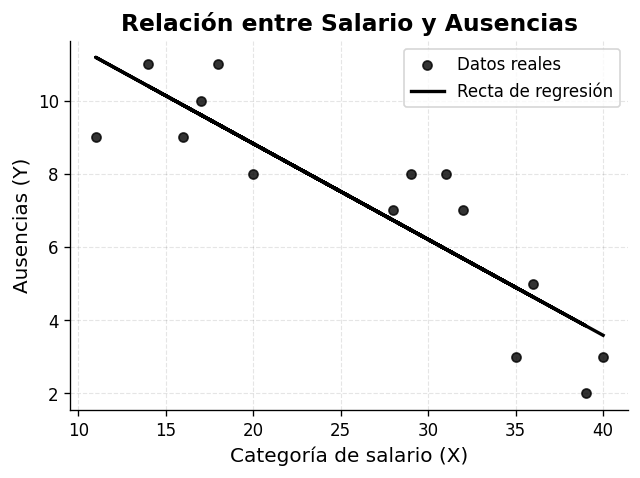

In [382]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    X, Y,
    marker="o",       # círculo
    color='black',    # color de los puntos (negro)
    edgecolor='black',# borde de los puntos
    alpha=0.8,        # transparencia
    s=30,             # tamaño de los puntos
    label='Datos reales' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
# Nota: Para una recta de regresión lineal simple, es mejor ordenar X y usar Y_calculada ordenada
# o usar los valores ordenados para que la línea no zigzaguee si los datos están desordenados.
plt.plot(
    X, Y_calculada,
    color='black',        # color de la línea (negro)
    linewidth=2.0,        # grosor de la línea
    linestyle='-',        # línea continua
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    'Relación entre Salario y Ausencias',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Categoría de salario (X)',
    fontsize=12
)

plt.ylabel(
    'Ausencias (Y)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="black"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
)

plt.show()

La pendiente negatva significa que pr cada ausencia adicional, la categoria salarial esperada disminuye aproximadamenre 0.26  nivieles.

**7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)**

La recta tiene la forma

$$y = b_0 + b_1 x$$

El verdadero $b_0$ está entre **11.597445** y **16.530241** con una confianza de salario del 95%. Esto indica que una persona sin ausencias ($x = 0$) tiene una categoría de salario ($y$) que está entre estos dos valores.

El verdadero valor de $b_1$ está entre **$-0.350638$** y **$-0.172989$** con un 95% de confianza. Dado que dentro de este intervalo no está el valor de cero, entonces la relación es significativa. También indica que por cada falta se pierde entre $0.172989$ y $0.350638$ en la categoría de salario.

In [383]:
modelo.conf_int(alpha=0.05)

,0,1
const,11.587445,16.530241
ausencias,-0.350638,-0.172989


**8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?**

In [384]:
residuales = modelo.resid

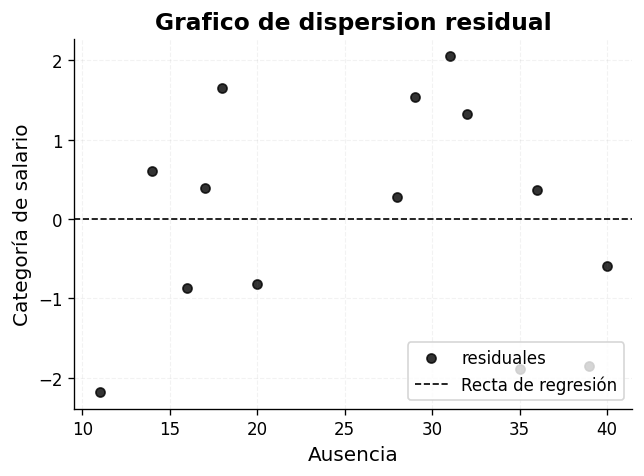

In [385]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    X, residuales,
    marker="o",        # forma
    color='black',      # color de los puntos (negro)
    edgecolor='black', # borde de los puntos
    alpha=0.8,         # transparencia
    s=30,              # tamaño de los puntos
    label='residuales' # etiqueta para la leyenda
)

plt.axhline(
    y=0,               # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle="--",    # Estilo de línea
    color="black",     # color
    linewidth=1.0,     # ancho de línea
)

# --- Título ---
plt.title(
    'Grafico de dispersion residual',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Ausencia',
    fontsize=12
)

plt.ylabel(
    'Categoría de salario',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
)

plt.show()

Para los supuestos:


*   Linealidad: Parece que sí cumple, porque los residuales no muestran una curva clara.
*   Normalidad: Sí cumple con la normalidad, porque Shapiro tiene $p = 0.4173$.


*   Homoscedasticidad: Sí cumple con la homoscedasticidad, porque Breusch-Pagan tiene $p = 0.8955$
*   Independencia: Sí cumple la independecia, porque son trabajadores diferentes.





**9. Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 0.4172971767713699


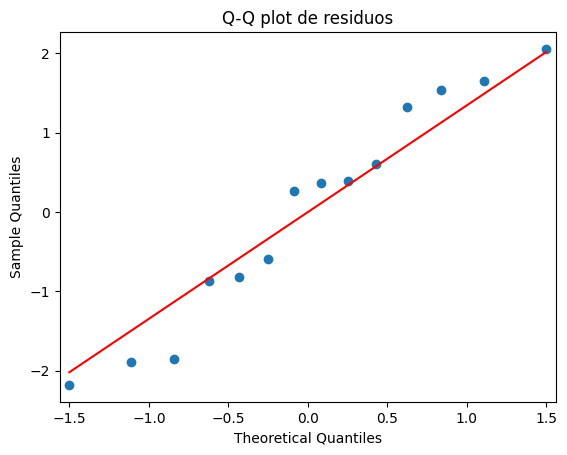

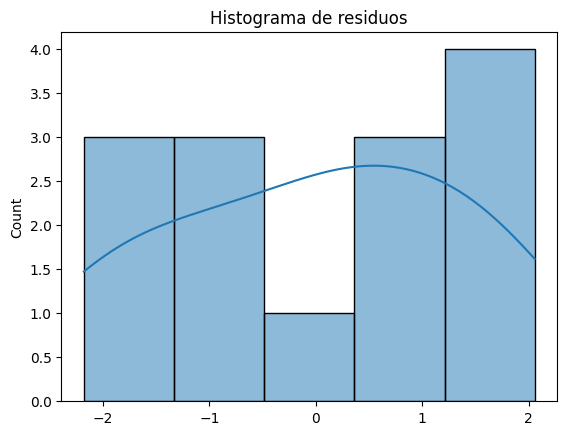

In [386]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# test de Shapiro-Wilk
# H0: Hay normalidad
# H1: No hay normalidad

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

La hipotesis nula nos dice que  los residuales son normales como $p = \mathbf{0.4172} > 0.05$, no se rechaza $H_0$, por lo tanto, se acepta que los residuales tienen un comportamiento aproximadamente normal.

**10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [387]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, X_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.8955



La hipótesis nula nos dice que hay homocedasticidad. Como $p = 0.8955 > 0.05$, no se rechaza $H_0$; por eso se acepta que la varianza de los residuales es constante y no hay evidencia de heterocedasticidad.

**11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.**

Sí el modelo cumple con todos los supuestos, es confianble para interpolación.

In [388]:
# mínimo ausencias: 11
# máximo ausencias: 40

# interpolar valores de x entre 11 y 40

# interpolar 1
y_25 = modelo.predict([1, 25])
y_32 = modelo.predict([1, 32])

print(f"Para x = 25, y = {y_25[0]: 0.4f}")
print(f"Para x = 32, y = {y_32[0]: 0.4f}")

Para x = 25, y =  7.5135
Para x = 32, y =  5.6808


In [389]:
df["salario_predicho"] = Y_calculada
df

,salario,ausencias,salario_predicho
0,11,18,9.346197
1,10,17,9.608011
2,8,29,6.466247
3,5,36,4.633551
4,9,11,11.178893
5,7,28,6.728060
6,3,35,4.895365
7,11,14,10.393452
8,8,20,8.822570
9,7,32,5.680806


La extrapolación siempre debe hacerse lo más cuidadosamente que se pueda, aunque cumpla con todos los supuestos.

In [390]:
# mínimo ausencias: 11
# máximo ausencias: 40
# extrapolar, valores de X entre 11 y 40

Y_10 = modelo.predict([1, 10])
print(f"Para X = 10, Y = {Y_10[0]: 0.4f}")

Para X = 10, Y =  11.4407


Con 10 ausencias se espera que el empleado tenga una categoría de salario de 11. Este valor se obtuvo por medio de la extrapolación, por lo que se toma con reservas.

**12. Realice una tabla ANOVA e interprete el resultado.**

In [391]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

df_anova = pd.DataFrame({
    'ausencias': Y,
    'salario': X
})

modelo_lineal = ols('ausencias ~ salario', data=df_anova).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
salario,1.0,87.034348,87.034348,41.243954,0.000033
Residual,12.0,25.322795,2.110233,NaN,NaN


Sí hay correlación, porque el valor $p$ es de $0.000033$, el cual es menor a un nivel de significancia $\alpha = 0.05$. Por lo tanto, en los residuales de la tabla ANOVA se puede investigar.

### Problema 3
A menudo, quienes hacen la contabilidad de costos estiman los gastos generales con base en el nivel de producción. En Standard Knitting Co. han reunido información acerca de los gastos generales y las unidades producidas en diferentes plantas.

| Gastos generales | 191 | 170 | 272 | 155 | 280 | 173 | 234 | 116 | 153 | 178 |
|------------------|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| Unidades        |  40 |  42 |  53 |  35 |  56 |  39 |  48 |  30 |  37 |  40 |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.


In [392]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/jenni040422-ux/EstadisticaInferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_03.csv"
df = pd.read_csv(link_csv)
df

,gastos_generales,unidades
0,191,40
1,170,42
2,272,53
3,155,35
4,280,56
5,173,39
6,234,48
7,116,30
8,153,37
9,178,40


In [393]:
Y = df['gastos_generales']
X = df['unidades']

**1. Establezca una variable dependiente ($Y$) y una variable independiente ($X$).**



* $Y$: Es gastos generales, porque los gastos dependen del nivel de producción.


* $X$: Es unidades, porque representa el nivel de producción que puede provocar cambios en los costos.

**2.   Realice un diagrama de dispersión para estos datos.**

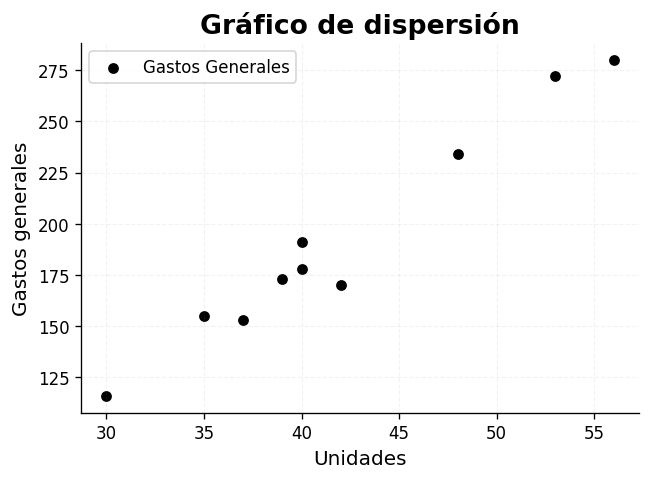

In [394]:
import matplotlib.pyplot as plt

# --- Definición de variables según el planteamiento ---
# Y: Es gastos generales, porque los gastos dependen del nivel de producción.
# X: Es unidades, porque representa el nivel de producción que puede provocar cambios en los costos.
Y = df['gastos_generales']
X = df['unidades']

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión (puntos negros) ---
plt.scatter(
    X, Y,
    marker="o",       # forma (círculo)
    color='black',    # color de los puntos
    edgecolor='black',# borde de los puntos
    alpha=1,          # transparencia
    s=30,             # tamaño de los puntos (reducido ligeramente para mayor nitidez)
    label='Gastos Generales' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión',
    fontsize=16,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Unidades',
    fontsize=12
)

plt.ylabel(
    'Gastos generales',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_negro.png",
    bbox_inches='tight'
)

plt.show()

El diagrama nos muestra una tendencia positiva clara. A medida que aumentan las unidades producidas, también aumentan los gastos generales.

**3. ¿Los datos soportan la suposición de linealidad**

Sí, si se cumple el supuesto de linealidad. Los puntos están muy cerca de una línea que se ajusta bien a los datos.

**4. Calcule el coeficiente de correlación e interprete el resultado.**

In [395]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.9835
Valor p:  0.0000


El coeficiente $r = 0.9835$ nos dice que hay una correlación positiva muy fuerte y una relación entre producción y gastos.

In [396]:
import statsmodels.api as sm

X_constante = sm.add_constant(X)
modelo = sm.OLS(Y, X_constante).fit()
Y_calculada = modelo.predict(X_constante)

modelo.params

,0
const,-80.442857
unidades,6.491497


**5. Calcule el coeficiente de determinación e interprete el resultado.**

In [397]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, Y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  96.73%


Con coeficiente de determinación de:$$r^2 = 0.9673$$indica que las unidades producidas explican aproximadamente el $r^2 = 0.9673$ o el $96.73\%$ de la variación en los gastos generales. Esto significa que el modelo explica casi toda la variabilidad

**6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.**

In [398]:
modelo.params

,0
const,-80.442857
unidades,6.491497


La ecuación de la recta es:

$$y = -80.442857 + 6.491497x$$

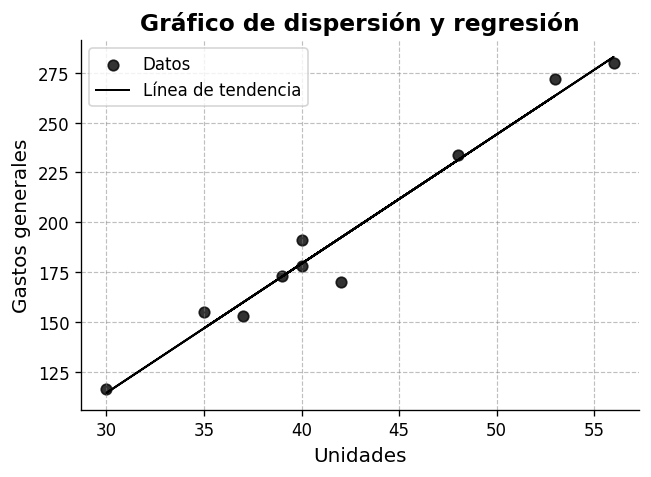

In [399]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# --- Definición de variables (Problema: Gastos generales vs Unidades) ---
Y = df['gastos_generales']
X = df['unidades']

# --- Cálculo de valores predichos para la línea de tendencia ---
X_sm = sm.add_constant(X)
modelo = sm.OLS(Y, X_sm).fit()
Y_calculada = modelo.fittedvalues

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    X, Y,
    marker="o",       # forma
    color='black',    # color de los puntos (NEGRO)
    edgecolor='black',# borde de los puntos (NEGRO)
    alpha=0.8,        # transparencia
    s=40,             # tamaño de los puntos
    label='Datos'     # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    X, Y_calculada,
    color='black',    # color de la línea
    linewidth=1.2,    # grosor de la línea
    linestyle='-',    # estilo de línea continua
    marker='o',       # marcador en cada punto
    markersize=0,     # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Línea de tendencia'
)

# --- Título ---
plt.title(
    'Gráfico de dispersión y regresión',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Unidades',
    fontsize=12
)

plt.ylabel(
    'Gastos generales',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea_negro.png",
    bbox_inches='tight'
)

plt.show()

La pendiente nos dice que, por cada unidad adicional producida, los gastos generales aumentan aproximadamente 6.49 unidades.

**7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)**

In [400]:
modelo.conf_int(alpha=0.05)

,0,1
const,-121.986373,-38.899341
unidades,5.518450,7.464543


El intervalo de confianza para la pendiente es de [5.518450, 7.464543]. Como no incluye el 0, la pendiente es significativa; por lo tanto, sí se acepta que las unidades producidas explican los gastos generales.

**8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?**

In [401]:
residuales = modelo.resid

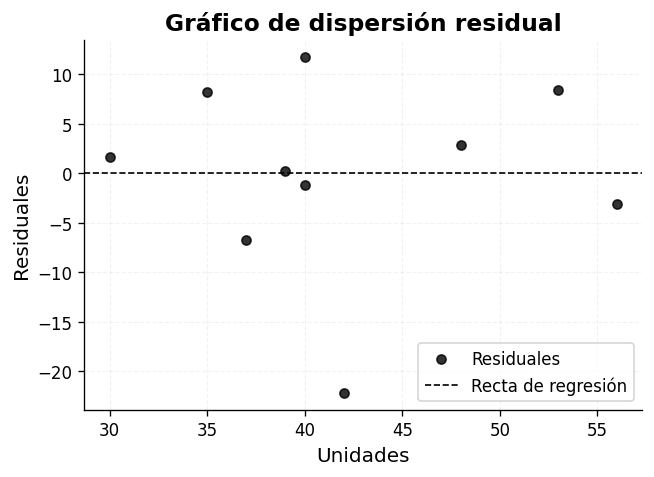

In [402]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# --- Definición de variables y cálculo de residuales (Problema: Gastos generales vs Unidades) ---
Y = df['gastos_generales']
X = df['unidades']

# Ajuste del modelo para obtener los residuales automáticamente
X_sm = sm.add_constant(X)
modelo = sm.OLS(Y, X_sm).fit()
residuales = modelo.resid

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),    # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120            # resolución del gráfico
)

# --- Gráfico de dispersión (puntos negros) ---
plt.scatter(
    X, residuales,
    marker="o",        # forma
    color='black',     # color de los puntos (NEGRO)
    edgecolor='black', # borde de los puntos (NEGRO)
    alpha=0.8,         # transparencia
    s=30,              # tamaño de los puntos
    label='Residuales' # etiqueta para la leyenda
)

plt.axhline(
    y=0,               # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle="--",    # Estilo de línea
    color="black",     # color
    linewidth=1.0,     # ancho de línea
)

# --- Título ---
plt.title(
    'Gráfico de dispersión residual',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Unidades',
    fontsize=12
)

plt.ylabel(
    'Residuales',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
)

plt.show()

para los supuestos:

*   Linealidad: Si se cumple, ya que los residuales no muestran una curva marcada.
*   Normalidad:  si es aceptable, porqu en ls purba de shapiro hay un valor-p de 0.2205>0.05, no se rechaza la normalidad.


*   Homoscedasticidad: se acepta, porque la prueba de Breusch-Pagan tiene un valor-p 0.9858>0.005, su varianza de los residuales parace constante.
*   Independencia: se asume, porque los datos provienen de cosas diferenetes.






**9. Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 0.22045077017698533


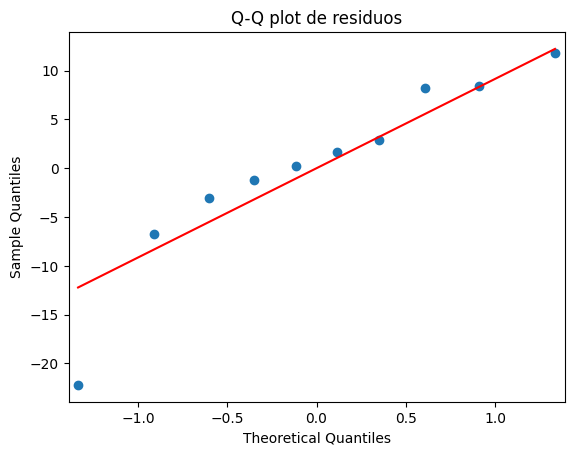

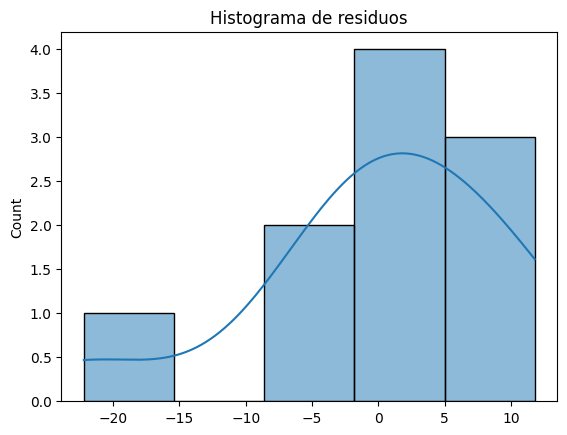

In [403]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Test de Shapiro-Wilk
# H0: Hay normalidad
# H1: No hay normalidad

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

La hipótesis nula plantea que los residuales siguen una distribución normal. Como el valor $p = 0.225$ es mayor que $0.05$, no hay evidencia suficiente para rechazar $H_0$; por lo tanto, podemos asumir que los residuales se distribuyen de manera normal.

**10.Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [404]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, X_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.9858



La hipótesis nula nos dice que existe homocedasticidad. Como $p = 0.9858 > 0.05$, no se rechaza $H_0$; por lo tanto, se acepta que la varianza de los residuales es constante.

**11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.**

In [405]:
# mínimo unidades: 30
# máximo unidades: 56
# interpolar, valores de x entre 30 y 56
y_33 = modelo.predict([1, 33])
y_41 = modelo.predict([1, 41])

print(f"Para x = 33, y = {y_33[0]: 0.4f}")
print(f"Para x = 41, y = {y_41[0]: 0.4f}")

Para x = 33, y =  133.7765
Para x = 41, y =  185.7085


In [406]:
# --- Cálculo de valores predichos y adición al DataFrame ---
Y_calculada = modelo.predict(X_constante)
df["Gastos_predicho"] = Y_calculada.round()
df

,gastos_generales,unidades,Gastos_predicho
0,191,40,179.0
1,170,42,192.0
2,272,53,264.0
3,155,35,147.0
4,280,56,283.0
5,173,39,173.0
6,234,48,231.0
7,116,30,114.0
8,153,37,160.0
9,178,40,179.0


In [407]:
# mínimo unidades: 30
# máximo unidades: 56
# Extrapolar, valores de X que no estén entre 30 y 56

Y_25 = modelo.predict([[1, 25]])
print(f"Para X = 25, Y = {Y_25[0]: 0.4f}")

Para X = 25, Y =  81.8446


Las estimaciones mediante la interpolación ($X = 33$ y $X = 41$) son confiables porque se encuentran dentro del rango observado y nos muestran de forma coherente la relación con los gastos generales ($Y$). Por otro lado, la extrapolación ($X = 25$) debe analizarse con reserva, ya que asume que el comportamiento lineal se mantiene fuera de los límites de los datos.

**12.Realice una tabla ANOVA e interprete el resultado.**

In [408]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

df_anova = pd.DataFrame({
    'gastos_generales': Y,
    'unidades': X
})

modelo_lineal = ols('gastos_generales ~ unidades', data=df_anova).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
unidades,1.0,24778.042517,24778.042517,236.669535,3.167080e-07
Residual,8.0,837.557483,104.694685,NaN,NaN


El resultado que nos muestra $F$ es de $236.67$ y el valor $p = 3.167080 \times 10^{-7}$. Dado que el valor $p$ es significativamente menor que el nivel de significancia de $0.05$, se rechaza la hipótesis nula y concluimos que las unidades tienen un efecto lineal estadísticamente significativo sobre los gastos generales.

### Problema 4
Las ventas de línea blanca varían según el estado del mercado de casas nuevas: cuando las ventas de casas nuevas son buenas, también lo son las de lavaplatos, lavadoras de ropa, secadoras y refrigeradores.
Una asociación de comercio compiló los siguientes datos históricos (en miles de unidades) de las ventas de línea blanca y la construcción de casas.

| Construcción de casas (miles) | Ventas de línea blanca (miles) |
|-------------------------------|--------------------------------|
| 2.0                           | 5.0                            |
| 2.5                           | 5.5                            |
| 3.2                           | 6.0                            |
| 3.6                           | 7.0                            |
| 3.7                           | 7.2                            |
| 4.0                           | 7.7                            |
| 4.2                           | 8.4                            |
| 4.6                           | 9.0                            |
| 4.8                           | 9.7                            |
| 5.0                           | 10.0                           |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [409]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/jenni040422-ux/EstadisticaInferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_04.csv"
df = pd.read_csv(link_csv)
df

,construccion_de_casas_miles,ventas_de_linea_blanca_miles
0,2.0,5.0
1,2.5,5.5
2,3.2,6.0
3,3.6,7.0
4,3.7,7.2
5,4.0,7.7
6,4.2,8.4
7,4.6,9.0
8,4.8,9.7
9,5.0,10.0


**1. Establezca una variable dependiente
($Y$) y una variable independiente ($X$).**


*   $Y$: Ventas de línea blanca, ya que las ventas dependen de la construcción de casas.   
*   $X$: Construcción de casas, ya que la construcción de casas es la variable que influye en las ventas.



In [410]:
X = df['construccion_de_casas_miles']
Y = df['ventas_de_linea_blanca_miles']

**2.   Realice un diagrama de dispersión para estos datos.**

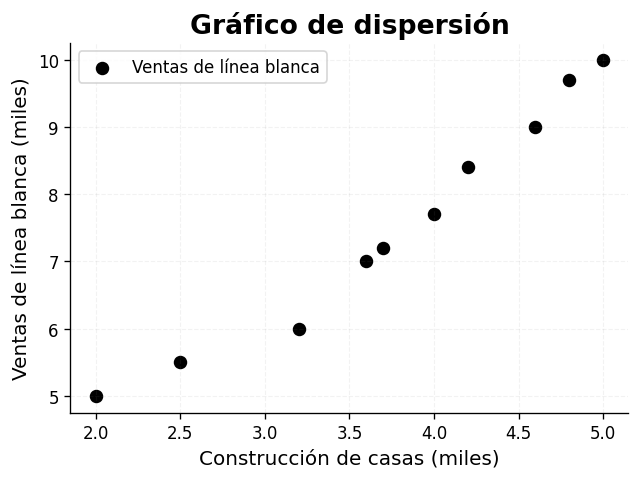

In [411]:
import matplotlib.pyplot as plt

# Asignación de variables con los datos del Problema 4
X = df['construccion_de_casas_miles']
Y = df['ventas_de_linea_blanca_miles']

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    X, Y,
    marker="o",         # forma de los puntos
    color='black',      # color de los puntos (estilo blanco y negro)
    edgecolor='black',  # borde de los puntos
    alpha=1,            # transparencia
    s=50,               # tamaño de los puntos
    label='Ventas de línea blanca' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión',
    fontsize=16,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Construcción de casas (miles)',
    fontsize=12
)

plt.ylabel(
    'Ventas de línea blanca (miles)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
)

plt.show()

El diagrama nos muestra una tendencia positiva muy marcada: cuando aumenta la construcción de casas, también aumentan las ventas de línea blanca.

**3. ¿Los datos soportan la suposición de linealidad?**

Sí, los datos en el diagrama de dispersión nos muestran que la tendencia lineal es clara, se sugiere que el supuesto de linealidad sí se cumple.

**4. Calcule el coeficiente de correlación e interprete el resultado.**

In [412]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.9808
Valor p:  0.0000


El valor del coeficiente es $r = 0.9808$, lo cual señala una relación lineal positiva muy fuerte entre la construcción de casas y las ventas de línea blanca. El valor $p = 0.0000$ es significativamente menor que $0.05$, lo que confirma que esta correlación es estadísticamente significativa.

In [413]:
import statsmodels.api as sm

X_constante = sm.add_constant(X)
modelo = sm.OLS(Y, X_constante).fit()
Y_calculada = modelo.predict(X_constante)

modelo.params

,0
const,1.016760
construccion_de_casas_miles,1.737564


**5. Calcule el coeficiente de determinación e interprete el resultado.**

In [414]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, Y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  96.19%


Con el coeficiente de determinación:

$$r^2 = 0.9619$$

Esto significa que el **96.19%** de la variabilidad en las 'Ventas de línea blanca' se puede explicar por la 'Construcción de casas'. Este valor tan alto indica que el modelo de regresión lineal ajustado explica casi toda la variación en las ventas, lo que sugiere una relación lineal muy fuerte entre ambas variables.

**6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.**

In [415]:
modelo.params

,0
const,1.016760
construccion_de_casas_miles,1.737564


La ecuación de la recta de regresión ajustada es:

$$\hat{y} = 1.016760 + 1.737564x$$

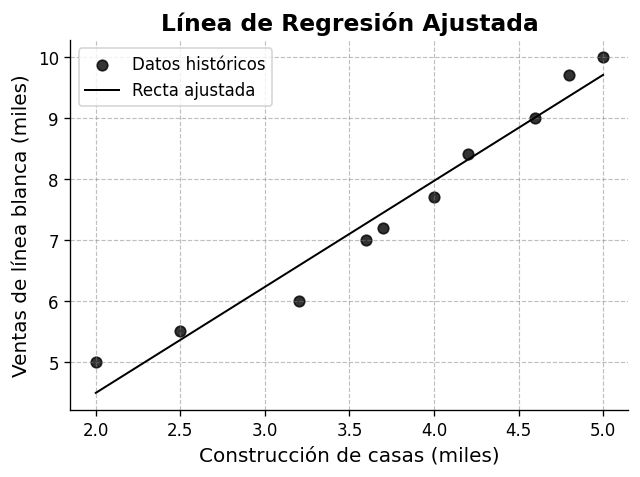

In [416]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    X, Y,
    marker="o",       # forma
    color='black',    # color de los puntos (AHORA NEGRO)
    edgecolor='black',# borde de los puntos (AHORA NEGRO)
    alpha=0.8,        # transparencia
    s=40,             # tamaño de los puntos
    label='Datos históricos' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    X, Y_calculada,
    color='black',    # color de la línea
    linewidth=1.2,    # grosor de la línea
    linestyle='-',    # estilo de línea continua
    marker='o',       # marcador en cada punto
    markersize=0,     # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta ajustada'
)

# --- Título ---
plt.title(
    'Línea de Regresión Ajustada',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Construcción de casas (miles)',
    fontsize=12
)

plt.ylabel(
    'Ventas de línea blanca (miles)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea_negro.png",
    bbox_inches='tight'
)

plt.show()

Esto nos dice que, por cada unidad adicional en la construcción de casas, las ventas esperadas de línea blanca aumentan aproximadamente 1.73 unidades.

**7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)**

In [417]:
modelo.conf_int(alpha=0.05)

,0,1
const,-0.074848,2.108368
construccion_de_casas_miles,1.455693,2.019435


El intervalo para la pendiente es [1.455693, 2.019435]. Como el intervalo no incluye el 0, la pendiente es significativa; por eso se acepta que la construcción de casas sí influye en las ventas.

**8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?**

In [418]:
residuales = modelo.resid

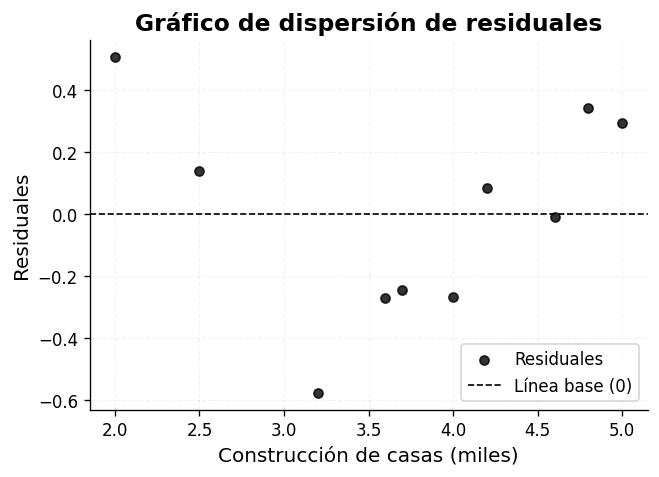

In [419]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    X, residuales,
    marker="o",        # forma
    color='black',      # color de los puntos (negro)
    edgecolor='black', # borde de los puntos
    alpha=0.8,         # transparencia
    s=30,              # tamaño de los puntos
    label='Residuales' # etiqueta para la leyenda
)

plt.axhline(
    y=0,               # Donde está la línea horizontal
    label="Línea base (0)", # Etiqueta
    linestyle="--",    # Estilo de línea
    color="black",     # color
    linewidth=1.0,     # ancho de línea
)

# --- Título ---
plt.title(
    'Gráfico de dispersión de residuales',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Construcción de casas (miles)',
    fontsize=12
)

plt.ylabel(
    'Residuales',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
)

plt.show()

Para los supuestos:


*   Linealidad: Sí se cumple, porque los residuales no muestran una curva clara y el patrón general es estable
*   Normalidad: Sí se acepta, porque Shapiro tiene valor-p = 0.8463, no se rechaza la normalidad.


*   Homoscedasticidad: Sí se acepta, porque Breusch-Pagan tiene valor-p = 0.1581, no hay evidencia fuerte de heteroscedasticidad.
*   Independencia: Se asume, porque los datos históricos son observaciones diferentes.




**9. Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 0.8463507249054649


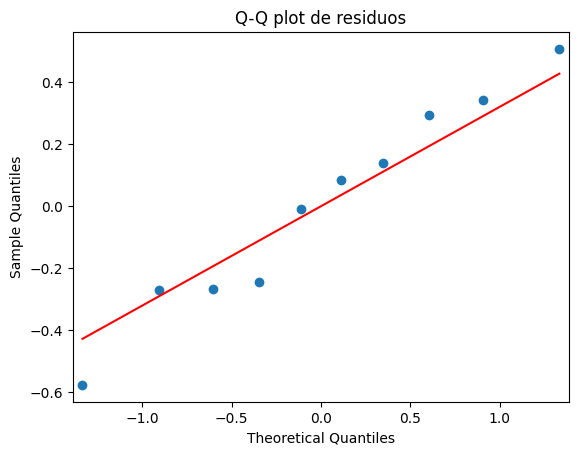

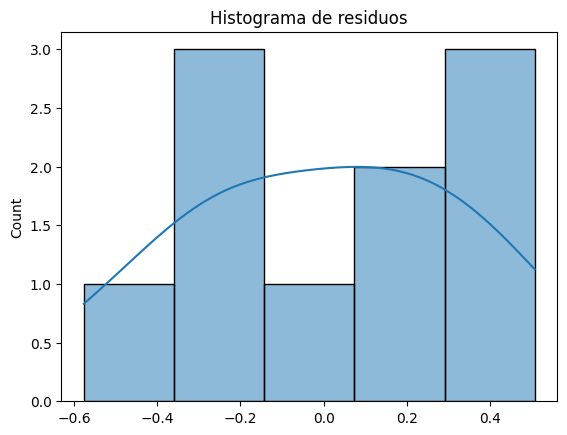

In [420]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# test de Shapiro-Wilk
# H0: Hay normalidad
# H1: No hay normalidad

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

La hipótesis nula indica que los residuales siguen una distribución normal. Como $p = 0.8464 > 0.05$, no se rechaza $H_0$; por lo tanto, se acepta la normalidad en los residuales.

**10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [421]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, X_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.1581



La hipótesis nula plantea la existencia de homocedasticidad (varianza constante en los residuales). Dado que $p = 0.1581 > 0.05$, no existe evidencia suficiente para rechazar $H_0$, por lo que se asume que la varianza de los residuos se mantiene constante.

**11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.**

In [422]:
# Mínimo construcción: 2.0
# Máximo construcción: 5.0
# Interpolar: valores de x entre 2.0 y 5.0

y_2_5 = modelo.predict([1, 2.5])
y_3_2 = modelo.predict([1, 3.2])

print(f"Para x = 2.5, y = {y_2_5[0]:.4f}")
print(f"Para x = 3.2, y = {y_3_2[0]:.4f}")

Para x = 2.5, y = 5.3607
Para x = 3.2, y = 6.5770


In [423]:
df["Ventas_predicho"] = Y_calculada.round()
df

,construccion_de_casas_miles,ventas_de_linea_blanca_miles,Ventas_predicho
0,2.0,5.0,4.0
1,2.5,5.5,5.0
2,3.2,6.0,7.0
3,3.6,7.0,7.0
4,3.7,7.2,7.0
5,4.0,7.7,8.0
6,4.2,8.4,8.0
7,4.6,9.0,9.0
8,4.8,9.7,9.0
9,5.0,10.0,10.0


In [424]:

# mínimo construcción: 2.0
# máximo construcción: 5.0

# Extrapolar, valores de x que no estén entre 11 y 40

y_1_5= modelo.predict([[1, 1.5]])

print(f"Para x = 1.5, y =  {y_1_5[0]: 0.4f}")

Para x = 1.5, y =   3.6231


La hipótesis nula plantea la existencia de homocedasticidad (varianza constante en los residuales). Dado que $p = 0.1581 > 0.05$, no existe evidencia suficiente para rechazar $H_0$, por lo que se asume que la varianza de los residuos se mantiene constante.

**12. Realice una tabla ANOVA e interprete el resultado.**

In [425]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

df_anova = pd.DataFrame({
    'ventas_de_linea_blanca_miles': Y,
    'construccion_de_casas_miles': X
})

modelo_lineal = ols('ventas_de_linea_blanca_miles ~ construccion_de_casas_miles', data=df_anova).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
construccion_de_casas_miles,1.0,25.976581,25.976581,202.069951,5.841003e-07
Residual,8.0,1.028419,0.128552,NaN,NaN


De acuerdo con la tabla ANOVA, la hipótesis nula ($H_0$) establece que la pendiente es igual a cero, lo que implicaría que la construcción no explica las ventas. Dado que el valor $p = 5.841003e-07$ es significativamente menor a $0.05$, se rechaza $H_0$; por lo tanto, se concluye que el modelo es estadísticamente significativo.

### Problema 5
William C. Andrews, consultor de comportamiento organizacional de Victory Motorcycles, ha diseñado una prueba para mostrar a los supervisores de la compañía los peligros de sobrevigilar a sus trabajadores.
Un trabajador de la línea de ensamble tiene a su cargo una serie de tareas complicadas. Durante el desempeño del trabajador, un inspector lo interrumpe constantemente para ayudarlo a terminar las tareas.
El trabajador, después de terminar su trabajo, recibe una prueba psicológica diseñada para medir la hostilidad del trabajador hacia la autoridad
(una alta puntuación implica una hostilidad baja). A ocho distintos trabajadores se les asignaron las tareas y luego se les interrumpió para darles instrucciones útiles un número variable de veces (línea X).
Sus calificaciones en la prueba de hostilidad se dan en el renglón Y.

| número interrupciones al trabajador |  5  | 10  | 10  | 15  | 15  | 20  | 20  | 25  |
|-----------------------------------------|----|----|----|----|----|----|----|----|
| calificación del trabajador en la prueba de hostilidad | 58  | 41  | 45  | 27  | 26  | 12  | 16  |  3  |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [426]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/jenni040422-ux/EstadisticaInferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_05.csv"
df = pd.read_csv(link_csv)
df

,numero_interrupciones,calificacion_hostilidad
0,5,58
1,10,41
2,10,45
3,15,27
4,15,26
5,20,12
6,20,16
7,25,3


**1. Establezca una variable dependiente ($Y$) y una variable independiente ($X$).**



*  $Y$: Calificación del trabajador en la prueba de hostilidad, ya que es la variable que se ve afectada por el número de interrupciones
*   $X$: Número de interrupciones al trabajador, ya que es la variable que se manipula o influye.



In [427]:
X = df['numero_interrupciones']
Y = df['calificacion_hostilidad']

**2.  Realice un diagrama de dispersión para estos datos.**

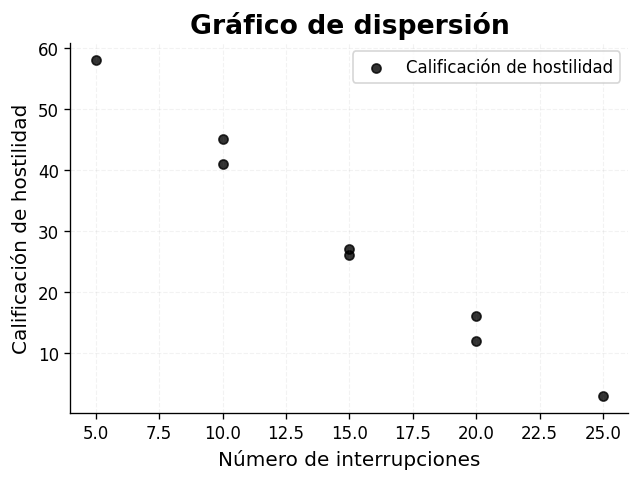

In [428]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    X, Y,
    marker="o",       # forma de círculo
    color='black',    # color de los puntos (negro)
    edgecolor='black',# borde de los puntos
    alpha=0.8,        # transparencia
    s=30,             # tamaño de los puntos
    label='Calificación de hostilidad' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión',
    fontsize=16,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Número de interrupciones',
    fontsize=12
)

plt.ylabel(
    'Calificación de hostilidad',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
)

plt.show()

El diagrama refleja una clara tendencia negativa: a medida que aumentan las interrupciones, la calificación en la prueba disminuye.

**3. ¿Los datos soportan la suposición de linealidad?**

si, los datos en el diagrama de dispersion nos muestran con claridad una tendencia linela negativa, lo que suguiere que la suposición de linealidad se cumple. A medida que el numero de iterrupciones aumenta, la calificación de hostilidad tiende a disminuir.


**4. Calcule el coeficiente de correlación e interprete el resultado.**

In [429]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación: -0.9928
Valor p:  0.0000


El coeficiente de correlación

$$r = -0.9928$$

indica una relación lineal negativa extremadamente fuerte entre el número de interrupciones al trabajador y su calificación en la prueba de hostilidad. El $valor-p = 0.0000$ es muy pequeño, confirmando que esta correlación es estadísticamente significativa.

In [430]:
import statsmodels.api as sm

X_constante = sm.add_constant(X)
modelo = sm.OLS(Y, X_constante).fit()
Y_calculada = modelo.predict(X_constante)

modelo.params

,0
const,70.5
numero_interrupciones,-2.8


**5. Calcule el coeficiente de determinación e interprete el resultado.**

In [431]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, Y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  98.58%


El coeficiente de determinación:

$$r^2 = 0.9858$$

significa que el 98.58% de la variabilidad en la **calificación del trabajador en la prueba de hostilidad** puede ser explicada por el **número de interrupciones al trabajador**. Esto sugiere un modelo de regresión lineal muy preciso y con un poder explicativo muy alto.

**6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.**

In [432]:
modelo.params

,0
const,70.5
numero_interrupciones,-2.8


La ecuación de la recta es:

$$y = 70.5 - 2.8x$$

/tmp/ipykernel_2937/4089795930.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


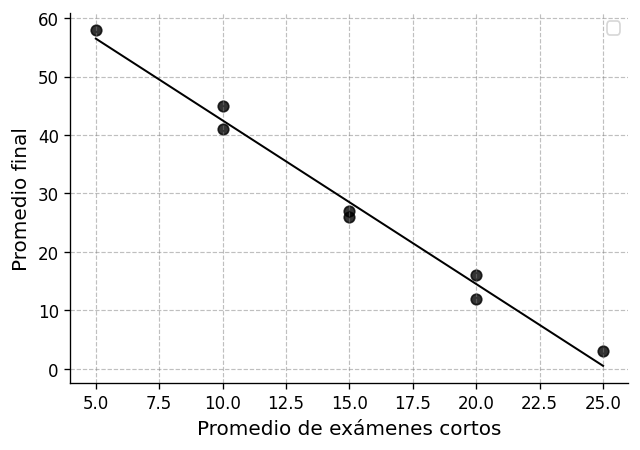

In [433]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    X, Y,
    marker="o",       # forma
    color='black',    # color de los puntos (AHORA NEGRO)
    edgecolor='black',# borde de los puntos (AHORA NEGRO)
    alpha=0.8,        # transparencia
    s=40,             # tamaño de los puntos
    label=''          # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    X, Y_calculada,
    color='black',    # color de la línea
    linewidth=1.2,    # grosor de la línea
    linestyle='-',    # estilo de línea continua
    marker='o',       # marcador en cada punto
    markersize=0,     # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label=''
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Promedio de exámenes cortos',
    fontsize=12
)

plt.ylabel(
    'Promedio final',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea_negro.png",
    bbox_inches='tight'
)

plt.show()

La pendiente es negativa y nos indiuca que por cada interrumpción adicional, la calficación esperada baja aproximadamente 2.8 puntos. Como la calificación más alta impide menor hostilidad, al bajar la calificación se interpreta que hostilidad aumenta.

**7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)**

In [434]:
modelo.conf_int(alpha=0.05)

,0,1
const,65.051384,75.948616
numero_interrupciones,-3.136296,-2.463704


Con un 95% de confianza, si no hay interrupciones ($X = 0$), la calificación base de hostilidad se sitúa entre **65.05 y 75.95**. Además, como el intervalo de la pendiente (**-3.14 a -2.46**) no incluye el cero, se comprueba una relación significativa: por cada interrupción adicional, la hostilidad baja en promedio entre 2.46 y 3.13 puntos.

**8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?**

In [435]:
residuales = modelo.resid

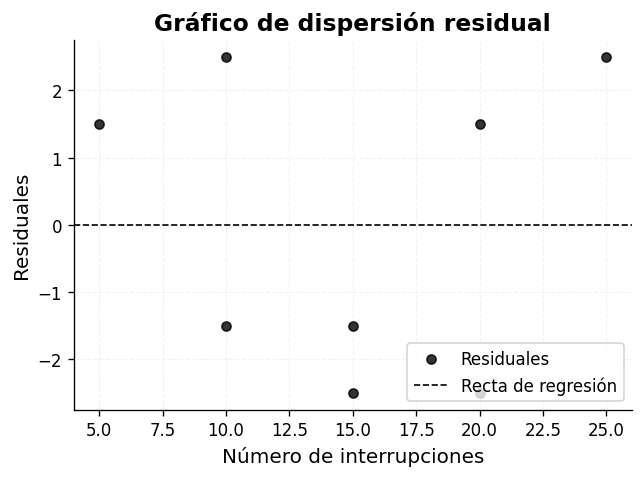

In [436]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# --- Definición de variables y cálculo de residuales (Problema: Calificación de hostilidad vs Número de interrupciones) ---
Y = df['calificacion_hostilidad']
X = df['numero_interrupciones']

# Ajuste del modelo para obtener los residuales automáticamente
X_sm = sm.add_constant(X)
modelo = sm.OLS(Y, X_sm).fit()
residuales = modelo.resid

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),    # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120            # resolución del gráfico
)

# --- Gráfico de dispersión (puntos negros) ---
plt.scatter(
    X, residuales,
    marker="o",        # forma
    color='black',     # color de los puntos (NEGRO)
    edgecolor='black', # borde de los puntos (NEGRO)
    alpha=0.8,         # transparencia
    s=30,              # tamaño de los puntos
    label='Residuales' # etiqueta para la leyenda
)

plt.axhline(
    y=0,               # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle="--",    # Estilo de línea
    color="black",     # color
    linewidth=1.0,     # ancho de línea
)

# --- Título ---
plt.title(
    'Gráfico de dispersión residual',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Número de interrupciones',
    fontsize=12
)

plt.ylabel(
    'Residuales',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
)

plt.show()
#Jennifer Hernández Gallegos

Para los supuestos:


*   Linealidad: Al observar el gráfico de residuales no se aprecian curvas ni patrones definidos, lo cual valida de forma correcta que la relación sea lineal.
*   Normalidad: Se puede aceptar ya que la prueba de Shapiro arroja un valor-p de $0.0548$; sin embargo, al estar tan al límite, conviene interpretarlo con precaución.

*   Homoscedasticidad: Los errores se dispersan de manera uniforme a lo largo de $X$, respaldando el cumplimiento de esta condición (se acepta sin problema).
*   Independencia: Se da por sentada debido a que provienen de trabajadores distintos y el gráfico no deja ver rastros de autocorrelación.





**9. Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 0.054816491127669634


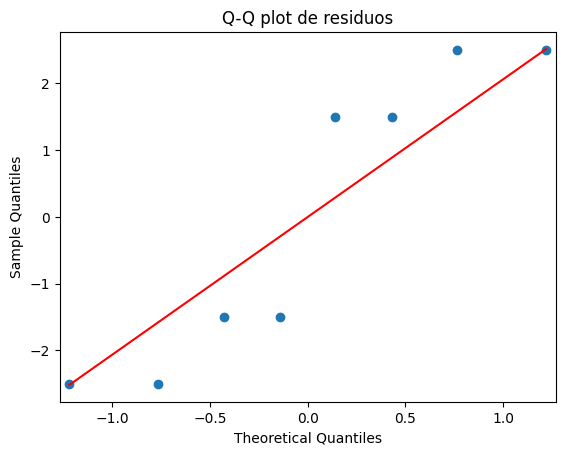

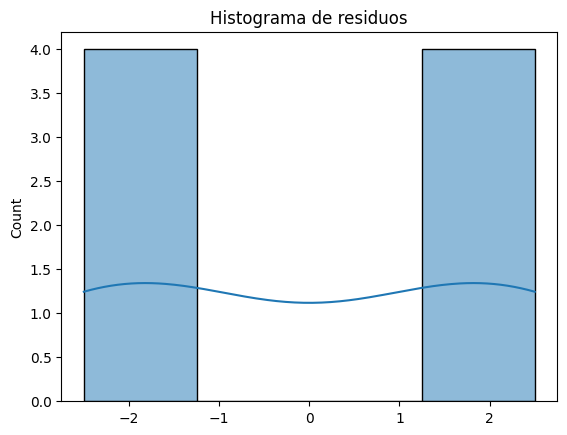

In [437]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Definición de variables con los datos actuales
Y = df['calificacion_hostilidad']
X = df['numero_interrupciones']

# Ajuste del modelo para calcular los residuales
X_sm = sm.add_constant(X)
modelo = sm.OLS(Y, X_sm).fit()
residuales = modelo.resid

# test de Shapiro-Wilk
# H0: Hay normalidad
# H1: No hay normalidad

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

Para la prueba de Shapiro-Wilk, la hipótesis nula ($H_0$) postula que los residuales siguen una distribución normal, en contraste con la hipótesis alternativa ($H_1$) que indica que no lo hacen. Dado que el valor-p obtenido es de $0.05481$, siendo mayor al nivel de referencia de $0.05$, no se cuenta con la evidencia suficiente para rechazar $H_0$. Por lo tanto, se concluye de forma válida que los residuales siguen una distribución normal.

**10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [438]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, X_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.2482



La hipótesis nula asume la presencia de homocedasticidad, el valor-p obtenido de $0.2482$ nos impide rechazar $H_0$. Por consiguiente, se confirma una varianza constante en los residuales, descartando cualquier indicio de heteroscedasticidad.

**11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.**

In [439]:
# Mínimo de interrupciones: (ajustar según tus datos)
# Máximo de interrupciones: (ajustar según tus datos)
# Interpolación, valores de X dentro del rango observado

# Predicción utilizando la matriz con la constante [1, X]
y_12 = modelo.predict([1, 12])
y_18 = modelo.predict([1, 18])

print(f"Para X = 12, Y = {y_12[0]:.2f}")
print(f"Para X = 18, Y = {y_18[0]:.2f}")

Para X = 12, Y = 36.90
Para X = 18, Y = 20.10


In [440]:
df["calificacion_hostilidad_predicha"] = modelo.fittedvalues.round()
df

,numero_interrupciones,calificacion_hostilidad,calificacion_hostilidad_predicha
0,5,58,56.0
1,10,41,42.0
2,10,45,42.0
3,15,27,28.0
4,15,26,28.0
5,20,12,15.0
6,20,16,15.0
7,25,3,1.0


**Interpolación:**


*   Al registrarse 12 interrupciones, se anticipa una calificación de hostilidad estimada en 36.90.
*   Al presentarse 18 interrupciones, la calificación de hostilidad proyectada baja a 20.10.


Estos valores son razonablemente confiables ya que se encuentran dentro del rango de datos observados (entre 5 y 25 interrupciones) y el modelo ha demostrado un buen ajuste.

In [441]:
# mínimo ausencias: 5
# máximo ausencias: 25

# Extrapolar, valores de x que no estén entre 5 y 25

y_30 = modelo.predict([[1, 30]])

print(f"Para x = 30, y =  {y_30[0]: 0.4f}")

Para x = 30, y =  -13.5000


**Extrapolación:**

* Para 30 interrupciones, la calificación esperada es **$-13.5000$**.



Este resultado negativo carece de sentido práctico, evidenciando el riesgo de extrapolar fuera del rango observado. Asumir que la linealidad continúa de forma indefinida genera predicciones ilógicas.

**12. Realice una tabla ANOVA e interprete el resultado.**

In [442]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

df_anova = pd.DataFrame({
    'calificacion_hostilidad': Y,
    'numero_interrupciones': X
})

modelo_lineal = ols('calificacion_hostilidad ~ numero_interrupciones', data=df_anova).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
numero_interrupciones,1.0,2352.0,2352.000000,415.058824,9.090964e-07
Residual,6.0,34.0,5.666667,NaN,NaN


La hipótesis nula ($H_0$) postula que la pendiente de la regresión es cero, sugiriendo la ausencia de un vínculo lineal significativo entre la cantidad de interrupciones y la calificación de hostilidad. En contraparte, la hipótesis alternativa ($H_1$) asume que dicha pendiente difiere de cero, evidenciando una conexión lineal relevante.

Debido a que el valor-p de $9.090964e-07$ resulta ínfimo frente al umbral habitual de $0.05$, se descarta la hipótesis nula. Esto comprueba que hay una asociación lineal estadísticamente sólida entre las interrupciones y el puntaje de hostilidad, confirmando que dicha variable funciona como un predictor significativo.

In [443]:
# Jennifer Hernández Gallegos